**LSTM**

In [1]:
# --- CELL 1 ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Konfigurasi plot agar lebih cantik
import seaborn as sns
sns.set(style="whitegrid")
print("Library berhasil di-load.")

Library berhasil di-load.


**XGBoost**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

In [2]:
df = pd.read_csv('data/data_udara_clean(update).csv')
df['waktu'] = pd.to_datetime(df['waktu'])
df = df.set_index('waktu')

In [3]:
def create_cyclical_features(df, target_col):
    data = df[[target_col]].copy()

    # Fitur Siklus Jam (Sangat Penting agar tidak mendatar)
    data['hour_sin'] = np.sin(2 * np.pi * data.index.hour / 24)
    data['hour_cos'] = np.cos(2 * np.pi * data.index.hour / 24)
    data['dayofweek'] = data.index.dayofweek

    # Fitur Lag (Gunakan lag yang lebih strategis: 1 jam, 2 jam, dan 24 jam yang lalu)
    lags = [1, 2, 48] # 48 titik = tepat 24 jam sebelumnya
    for lag in lags:
        data[f'lag_{lag}'] = data[target_col].shift(lag)

    return data.dropna()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3324\2757327719.py:64: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  future_index = pd.date_range(start=df_model.index[-1] + pd.Timedelta(minutes=30), periods=future_steps, freq='30T')


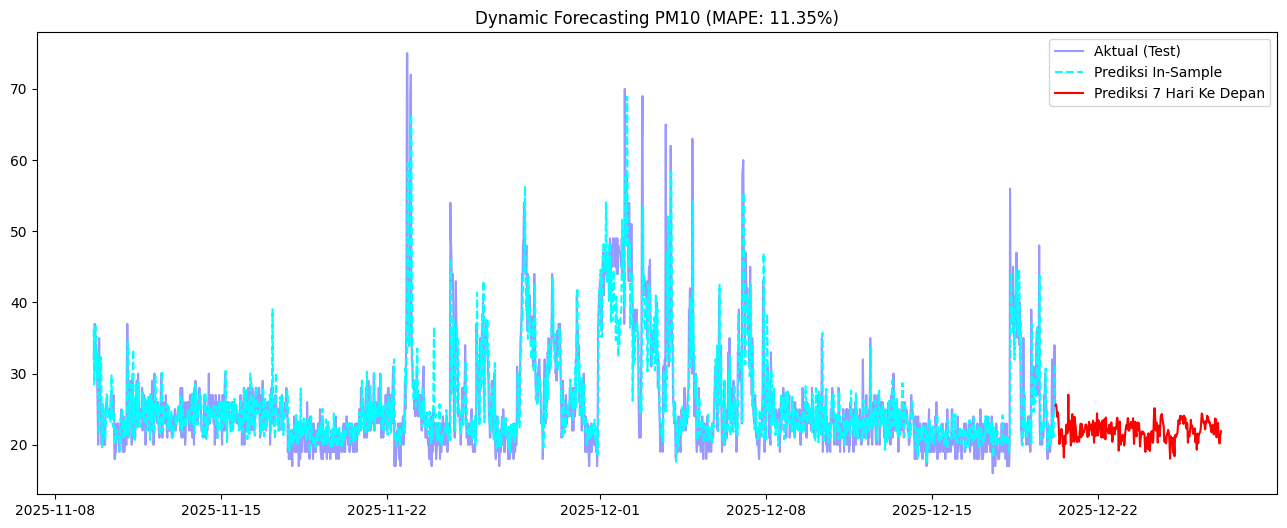

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3324\2757327719.py:64: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  future_index = pd.date_range(start=df_model.index[-1] + pd.Timedelta(minutes=30), periods=future_steps, freq='30T')


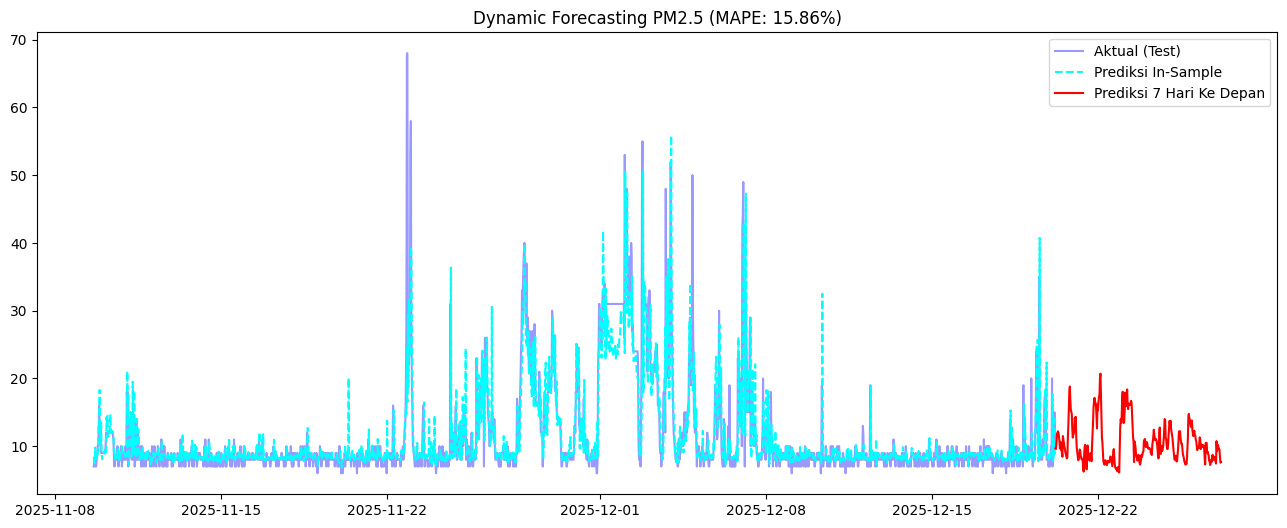

In [4]:
def run_dynamic_pipeline(target_name, full_df):
    # 1. Prepare Features
    df_model = create_cyclical_features(full_df, target_name)

    # 2. Split 70:20:10
    n = len(df_model)
    train_end = int(n * 0.7)
    val_end = int(n * 0.9)

    train = df_model.iloc[:train_end]
    val = df_model.iloc[train_end:val_end]
    test = df_model.iloc[val_end:]

    X_train, y_train = train.drop(columns=[target_name]), train[target_name]
    X_val, y_val = val.drop(columns=[target_name]), val[target_name]
    X_test, y_test = test.drop(columns=[target_name]), test[target_name]

    # 3. Model XGBoost dengan Parameter yang Lebih "Berani"
    model = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.08, # Menaikkan learning rate agar tidak terlalu smooth
        max_depth=8,        # Kedalaman pohon ditambah untuk menangkap variansi
        objective='reg:squarederror',
        n_jobs=-1
    )

    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    # 4. In-Sample Evaluation (Data Test)
    y_pred_test = model.predict(X_test)

    # 5. Out-of-Sample (7 Hari) - Teknik Direct + Recursive Hybrid
    future_steps = 336
    future_preds = []
    current_series = df_model[target_name].tolist()
    last_time = df_model.index[-1]

    for i in range(future_steps):
        next_time = last_time + pd.Timedelta(minutes=30)

        # Susun fitur untuk titik waktu ini
        feat_row = np.array([
            np.sin(2 * np.pi * next_time.hour / 24), # hour_sin
            np.cos(2 * np.pi * next_time.hour / 24), # hour_cos
            next_time.dayofweek,                     # dayofweek
            current_series[-1],                      # lag_1
            current_series[-2],                      # lag_2
            current_series[-48]                      # lag_48 (pola hari kemarin)
        ]).reshape(1, -1)

        pred = model.predict(feat_row)[0]
        future_preds.append(pred)
        current_series.append(pred) # Masukkan hasil untuk lag berikutnya
        last_time = next_time

    # 6. Plotting
    plt.figure(figsize=(16, 6))

    # Plot Data Test (In-Sample)
    plt.plot(y_test.index, y_test.values, label='Aktual (Test)', color='blue', alpha=0.4)
    plt.plot(y_test.index, y_pred_test, label='Prediksi In-Sample', color='cyan', linestyle='--')

    # Plot Future
    future_index = pd.date_range(start=df_model.index[-1] + pd.Timedelta(minutes=30), periods=future_steps, freq='30T')
    plt.plot(future_index, future_preds, label='Prediksi 7 Hari Ke Depan', color='red', linewidth=1.5)

    mape = mean_absolute_percentage_error(y_test, y_pred_test)

    plt.title(f"Dynamic Forecasting {target_name} (MAPE: {mape:.2%})")
    plt.legend()
    plt.show()

# Run
run_dynamic_pipeline('PM10', df)
run_dynamic_pipeline('PM2.5', df)

In [5]:
# Siapkan fitur dan bagi data
df_model = create_cyclical_features(df, 'PM10')

n = len(df_model)
train_end = int(n * 0.7)
val_end = int(n * 0.9)

train = df_model.iloc[:train_end]
val = df_model.iloc[train_end:val_end]
test = df_model.iloc[val_end:]

X_train, y_train = train.drop(columns=['PM10']), train['PM10']
X_val, y_val = val.drop(columns=['PM10']), val['PM10']
X_test, y_test = test.drop(columns=['PM10']), test['PM10']

# Latih model untuk PM10
model_pm10 = xgb.XGBRegressor(n_estimators=500, learning_rate=0.08, max_depth=8, objective='reg:squarederror', n_jobs=-1)
model_pm10.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# Prediksi dan evaluasi
y_pred = model_pm10.predict(X_test)

# Hitung MAPE dan RMSE
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== Evaluasi Model PM10 ===")
print(f"MAPE : {mape:.4f} ({mape*100:.2f}%)")
print(f"RMSE : {rmse:.4f}")

=== Evaluasi Model PM10 ===
MAPE : 0.1135 (11.35%)
RMSE : 4.6824


In [6]:
# Siapkan fitur dan bagi data
df_model = create_cyclical_features(df, 'PM2.5')

n = len(df_model)
train_end = int(n * 0.7)
val_end = int(n * 0.9)

train = df_model.iloc[:train_end]
val = df_model.iloc[train_end:val_end]
test = df_model.iloc[val_end:]

X_train, y_train = train.drop(columns=['PM2.5']), train['PM2.5']
X_val, y_val = val.drop(columns=['PM2.5']), val['PM2.5']
X_test, y_test = test.drop(columns=['PM2.5']), test['PM2.5']

# Latih model untuk PM2.5
model_pm25 = xgb.XGBRegressor(n_estimators=500, learning_rate=0.08, max_depth=8, objective='reg:squarederror', n_jobs=-1)
model_pm25.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# Prediksi dan evaluasi
y_pred = model_pm25.predict(X_test)

# Hitung MAPE dan RMSE
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== Evaluasi Model PM2.5 ===")
print(f"MAPE : {mape:.4f} ({mape*100:.2f}%)")
print(f"RMSE : {rmse:.4f}")

=== Evaluasi Model PM2.5 ===
MAPE : 0.1586 (15.86%)
RMSE : 4.1337
